In [10]:
# ============================================
# COMPETITIVE INTELLIGENCE DATABASE
# ============================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Create competitive intelligence database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

print("✅ Competitive Intelligence Database Initialized")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

# Create Comprehensive Tables
cursor.execute('''
CREATE TABLE approved_drugs (
    drug_id INTEGER PRIMARY KEY,
    brand_name TEXT,
    generic_name TEXT,
    company TEXT,
    therapy_class TEXT,
    mechanism TEXT,
    indication TEXT,
    launch_year INTEGER,
    peak_sales_usd_m INTEGER,
    current_market_share REAL,
    patent_expiry INTEGER,
    differentiation_score INTEGER CHECK(differentiation_score BETWEEN 1 AND 10)
)
''')

cursor.execute('''
CREATE TABLE pipeline_drugs (
    pipeline_id INTEGER PRIMARY KEY,
    drug_name TEXT,
    company TEXT,
    therapy_class TEXT,
    target TEXT,
    indication TEXT,
    development_stage TEXT,
    phase_start_year INTEGER,
    estimated_launch_year INTEGER,
    probability_of_success REAL,
    projected_peak_sales_usd_m INTEGER,
    competitive_threat_level TEXT
    -- Removed clinical_trial_id to match 13 columns
)
''')

cursor.execute('''
CREATE TABLE company_profiles (
    company_id INTEGER PRIMARY KEY,
    company_name TEXT,
    company_type TEXT,
    total_lung_cancer_revenue_usd_m INTEGER,
    number_of_approved_drugs INTEGER,
    number_of_pipeline_assets INTEGER,
    rdi_spend_usd_m INTEGER,
    strategic_focus TEXT,
    competitive_position TEXT
)
''')

cursor.execute('''
CREATE TABLE therapy_class_analysis (
    therapy_class TEXT PRIMARY KEY,
    approved_drugs_count INTEGER,
    pipeline_drugs_count INTEGER,
    total_market_share REAL,
    cagr_2024_2030 REAL,
    competitive_intensity TEXT,
    white_space_score INTEGER
)
''')

print("✅ 4 core competitive intelligence tables created")
print("   • approved_drugs - Commercial performance")
print("   • pipeline_drugs - Future competition")
print("   • company_profiles - Player capabilities")
print("   • therapy_class_analysis - Market segment analysis")

# APPROVED DRUGS DATA (Top 15 lung cancer drugs)
approved_data = [
    (1, 'Keytruda', 'pembrolizumab', 'Merck & Co.', 'Immunotherapy', 'PD-1 inhibitor', 'NSCLC (PD-L1≥1%)', 2015, 25000, 22.5, 2028, 9),
    (2, 'Opdivo', 'nivolumab', 'Bristol Myers Squibb', 'Immunotherapy', 'PD-1 inhibitor', 'NSCLC (2L+)', 2015, 12000, 10.8, 2028, 7),
    (3, 'Tecentriq', 'atezolizumab', 'Roche', 'Immunotherapy', 'PD-L1 inhibitor', 'NSCLC (1L combo)', 2016, 8500, 7.7, 2029, 8),
    (4, 'Tagrisso', 'osimertinib', 'AstraZeneca', 'Targeted Therapy', 'EGFR T790M inhibitor', 'EGFRm NSCLC', 2015, 12000, 10.8, 2032, 10),
    (5, 'Imfinzi', 'durvalumab', 'AstraZeneca', 'Immunotherapy', 'PD-L1 inhibitor', 'Stage III NSCLC', 2018, 7000, 6.3, 2030, 8),
    (6, 'Gilotrif', 'afatinib', 'Boehringer Ingelheim', 'Targeted Therapy', 'EGFR inhibitor', 'EGFRm NSCLC', 2013, 1200, 1.1, 2025, 6),
    (7, 'Xalkori', 'crizotinib', 'Pfizer', 'Targeted Therapy', 'ALK/ROS1 inhibitor', 'ALK+ NSCLC', 2011, 800, 0.7, 2024, 7),
    (8, 'Alecensa', 'alectinib', 'Roche', 'Targeted Therapy', 'ALK inhibitor', 'ALK+ NSCLC', 2015, 3500, 3.2, 2028, 9),
    (9, 'Tafinlar+Mekinist', 'dabrafenib+trametinib', 'Novartis', 'Targeted Therapy', 'BRAF/MEK inhibitor', 'BRAF V600E NSCLC', 2017, 600, 0.5, 2027, 8),
    (10, 'Cyramza', 'ramucirumab', 'Eli Lilly', 'Targeted Therapy', 'VEGFR2 inhibitor', 'NSCLC (2L+)', 2014, 900, 0.8, 2025, 6),
    (11, 'Portrazza', 'necitumumab', 'Eli Lilly', 'Targeted Therapy', 'EGFR inhibitor', 'Squamous NSCLC', 2015, 300, 0.3, 2026, 5),
    (12, 'Lorbrena', 'lorlatinib', 'Pfizer', 'Targeted Therapy', 'ALK/ROS1 inhibitor', 'ALK+ NSCLC (3L+)', 2018, 1200, 1.1, 2033, 9),
    (13, 'Rozlytrek', 'entrectinib', 'Roche', 'Targeted Therapy', 'NTRK/ROS1 inhibitor', 'NTRK/ROS1+ NSCLC', 2019, 400, 0.4, 2034, 8),
    (14, 'Tepmetko', 'tepotinib', 'Merck KGaA', 'Targeted Therapy', 'MET inhibitor', 'METex14 NSCLC', 2021, 500, 0.5, 2035, 9),
    (15, 'Rybrevant', 'amivantamab', 'Johnson & Johnson', 'Targeted Therapy', 'EGFR/MET bispecific', 'EGFRex20 NSCLC', 2021, 800, 0.7, 2036, 10)
]

cursor.executemany('''
INSERT INTO approved_drugs VALUES (?,?,?,?,?,?,?,?,?,?,?,?)
''', approved_data)

# PIPELINE DATA (Late-stage pipeline) - Fixed to 12 values
pipeline_data = [
    (1, 'Dato-DXd', 'AstraZeneca/Daiichi Sankyo', 'ADC', 'TROP2', 'NSCLC (2L+)', 'Phase III', 2023, 2025, 0.75, 3500, 'High'),
    (2, 'Patritumab deruxtecan', 'Merck & Co./Daiichi Sankyo', 'ADC', 'HER3', 'EGFRm NSCLC', 'Phase III', 2023, 2026, 0.70, 2500, 'Medium'),
    (3, 'Tarlatamab', 'Amgen', 'BiTE', 'DLL3', 'SCLC', 'Phase III', 2022, 2025, 0.65, 1800, 'Medium'),
    (4, 'Zongertinib', 'Boehringer Ingelheim', 'Targeted Therapy', 'HER2', 'HER2m NSCLC', 'Phase III', 2024, 2027, 0.60, 1200, 'Medium'),
    (5, 'Sunvozertinib', 'Dizal Pharmaceutical', 'Targeted Therapy', 'EGFR', 'EGFRex20 NSCLC', 'Phase III', 2023, 2026, 0.55, 800, 'Low'),
    (6, 'Sabestomig', 'AstraZeneca', 'Immunotherapy', 'PD-1/TIM-3', 'NSCLC (1L)', 'Phase III', 2024, 2027, 0.50, 2000, 'High'),
    (7, 'Repotrectinib', 'Bristol Myers Squibb', 'Targeted Therapy', 'ROS1/TRK', 'ROS1+ NSCLC', 'Phase III', 2023, 2025, 0.68, 1500, 'Medium'),
    (8, 'MK-1084', 'Merck & Co.', 'Targeted Therapy', 'KRAS G12C', 'KRAS G12C NSCLC', 'Phase III', 2024, 2027, 0.65, 3000, 'High'),
    (9, 'BDC-1001', 'Bolt Biotherapeutics', 'Immunotherapy', 'HER2', 'HER2+ NSCLC', 'Phase II/III', 2023, 2026, 0.45, 600, 'Low'),
    (10, 'CAN04', 'Cantargia', 'Immunotherapy', 'IL1RAP', 'NSCLC (combo)', 'Phase III', 2023, 2026, 0.40, 400, 'Low')
]

cursor.executemany('''
INSERT INTO pipeline_drugs VALUES (?,?,?,?,?,?,?,?,?,?,?,?)
''', pipeline_data)

# COMPANY PROFILES DATA
company_data = [
    (1, 'Merck & Co.', 'Big Pharma', 28000, 2, 3, 2500, 'IO leadership + ADC partnerships', 'Leader'),
    (2, 'AstraZeneca', 'Big Pharma', 19000, 2, 3, 2200, 'IO + Targeted combo strategy', 'Leader'),
    (3, 'Bristol Myers Squibb', 'Big Pharma', 13000, 1, 2, 1800, 'IO maintenance + next-gen targeted', 'Strong'),
    (4, 'Roche', 'Big Pharma', 12500, 3, 2, 2000, 'Comprehensive portfolio + diagnostics', 'Strong'),
    (5, 'Pfizer', 'Big Pharma', 2000, 2, 1, 1200, 'Targeted therapy specialist', 'Moderate'),
    (6, 'Daiichi Sankyo', 'Specialty Pharma', 0, 0, 2, 800, 'ADC platform leader', 'Emerging'),
    (7, 'Amgen', 'Biotech', 0, 0, 1, 600, 'BiTE platform in SCLC', 'Niche'),
    (8, 'Boehringer Ingelheim', 'Pharma', 1200, 1, 1, 700, 'Targeted therapy focused', 'Moderate'),
    (9, 'Novartis', 'Big Pharma', 600, 1, 0, 900, 'Maintenance strategy', 'Moderate'),
    (10, 'Johnson & Johnson', 'Big Pharma', 800, 1, 0, 1500, 'Bispecific antibodies', 'Emerging')
]

cursor.executemany('''
INSERT INTO company_profiles VALUES (?,?,?,?,?,?,?,?,?)
''', company_data)

# THERAPY CLASS ANALYSIS
therapy_data = [
    ('Immunotherapy', 4, 3, 47.3, 6.8, 'High', 3),
    ('Targeted Therapy', 11, 6, 40.2, 12.5, 'Very High', 7),
    ('ADC', 0, 2, 0.0, 25.0, 'Medium', 9),
    ('Chemotherapy', 0, 0, 10.5, -3.2, 'Declining', 1),
    ('Other Novel Modalities', 0, 2, 2.0, 18.0, 'Low', 8)
]

cursor.executemany('''
INSERT INTO therapy_class_analysis VALUES (?,?,?,?,?,?,?)
''', therapy_data)

conn.commit()

print("✅ Competitive database populated")
print(f"   • {len(approved_data)} approved drugs")
print(f"   • {len(pipeline_data)} pipeline drugs")
print(f"   • {len(company_data)} company profiles")
print(f"   • {len(therapy_data)} therapy class analyses")

✅ Competitive Intelligence Database Initialized
📅 Analysis Date: 2026-01-06
✅ 4 core competitive intelligence tables created
   • approved_drugs - Commercial performance
   • pipeline_drugs - Future competition
   • company_profiles - Player capabilities
   • therapy_class_analysis - Market segment analysis
✅ Competitive database populated
   • 15 approved drugs
   • 10 pipeline drugs
   • 10 company profiles
   • 5 therapy class analyses


In [12]:
# QUERY 1: Market Concentration Analysis
query1 = '''
SELECT 
    company,
    COUNT(*) as drug_count,
    SUM(current_market_share) as total_market_share,
    SUM(peak_sales_usd_m) as total_peak_sales_usd_m,
    ROUND(AVG(differentiation_score), 1) as avg_differentiation,
    CASE 
        WHEN SUM(current_market_share) >= 10 THEN 'Market Leader'
        WHEN SUM(current_market_share) >= 5 THEN 'Strong Player'
        WHEN SUM(current_market_share) >= 1 THEN 'Niche Player'
        ELSE 'Minor Player'
    END as competitive_position
FROM approved_drugs
GROUP BY company
ORDER BY total_market_share DESC
'''

df_market_concentration = pd.read_sql_query(query1, conn)
print("📊 MARKET CONCENTRATION ANALYSIS")
print("=" * 85)

# Format the DataFrame properly
df_market_concentration['total_market_share'] = df_market_concentration['total_market_share'].apply(lambda x: f"{x:.1f}%")
df_market_concentration['total_peak_sales_usd_m'] = df_market_concentration['total_peak_sales_usd_m'].apply(lambda x: f"{x:,.0f}")

print(df_market_concentration.to_string(index=False))

📊 MARKET CONCENTRATION ANALYSIS
             company  drug_count total_market_share total_peak_sales_usd_m  avg_differentiation competitive_position
         Merck & Co.           1              22.5%                 25,000                  9.0        Market Leader
         AstraZeneca           2              17.1%                 19,000                  9.0        Market Leader
               Roche           3              11.3%                 12,400                  8.3        Market Leader
Bristol Myers Squibb           1              10.8%                 12,000                  7.0        Market Leader
              Pfizer           2               1.8%                  2,000                  8.0         Niche Player
           Eli Lilly           2               1.1%                  1,200                  5.5         Niche Player
Boehringer Ingelheim           1               1.1%                  1,200                  6.0         Niche Player
   Johnson & Johnson           1

In [14]:
# QUERY 2: Pipeline Intensity by Company
query2 = '''
SELECT 
    p.company,
    COUNT(*) as pipeline_count,
    SUM(CASE WHEN p.development_stage = 'Phase III' THEN 1 ELSE 0 END) as phase_iii_count,
    ROUND(AVG(p.probability_of_success), 3) as avg_success_probability,
    SUM(p.projected_peak_sales_usd_m) as total_projected_sales_usd_m,
    c.competitive_position as current_position
FROM pipeline_drugs p
LEFT JOIN company_profiles c ON p.company = c.company_name
GROUP BY p.company
ORDER BY pipeline_count DESC, total_projected_sales_usd_m DESC
'''

df_pipeline_intensity = pd.read_sql_query(query2, conn)
print("\n📈 PIPELINE INTENSITY BY COMPANY")
print("=" * 85)

# Format the DataFrame
df_pipeline_intensity['total_projected_sales_usd_m'] = df_pipeline_intensity['total_projected_sales_usd_m'].apply(lambda x: f"{x:,.0f}")

print(df_pipeline_intensity.to_string(index=False))


📈 PIPELINE INTENSITY BY COMPANY
                   company  pipeline_count  phase_iii_count  avg_success_probability total_projected_sales_usd_m current_position
AstraZeneca/Daiichi Sankyo               1                1                     0.75                       3,500             None
               Merck & Co.               1                1                     0.65                       3,000           Leader
Merck & Co./Daiichi Sankyo               1                1                     0.70                       2,500             None
               AstraZeneca               1                1                     0.50                       2,000           Leader
                     Amgen               1                1                     0.65                       1,800            Niche
      Bristol Myers Squibb               1                1                     0.68                       1,500           Strong
      Boehringer Ingelheim               1               

In [15]:
# QUERY 3: Therapy Class Competitive Landscape
query3 = '''
SELECT 
    t.therapy_class,
    t.approved_drugs_count,
    t.pipeline_drugs_count,
    t.total_market_share || '%' as market_share,
    t.cagr_2024_2030 || '%' as projected_cagr,
    t.competitive_intensity,
    t.white_space_score,
    CASE 
        WHEN t.white_space_score >= 8 THEN 'High Opportunity'
        WHEN t.white_space_score >= 6 THEN 'Moderate Opportunity'
        ELSE 'Crowded'
    END as opportunity_assessment
FROM therapy_class_analysis t
ORDER BY t.white_space_score DESC, t.cagr_2024_2030 DESC
'''

df_therapy_landscape = pd.read_sql_query(query3, conn)
print("\n🎯 THERAPY CLASS COMPETITIVE LANDSCAPE")
print("=" * 90)
print(df_therapy_landscape.to_string(index=False))


🎯 THERAPY CLASS COMPETITIVE LANDSCAPE
         therapy_class  approved_drugs_count  pipeline_drugs_count market_share projected_cagr competitive_intensity  white_space_score opportunity_assessment
                   ADC                     0                     2         0.0%          25.0%                Medium                  9       High Opportunity
Other Novel Modalities                     0                     2         2.0%          18.0%                   Low                  8       High Opportunity
      Targeted Therapy                    11                     6        40.2%          12.5%             Very High                  7   Moderate Opportunity
         Immunotherapy                     4                     3        47.3%           6.8%                  High                  3                Crowded
          Chemotherapy                     0                     0        10.5%          -3.2%             Declining                  1                Crowded


In [16]:
# QUERY 4: Patent Cliff Analysis
query4 = '''
SELECT 
    patent_expiry,
    COUNT(*) as drugs_expiring,
    GROUP_CONCAT(brand_name, ', ') as expiring_drugs,
    SUM(current_market_share) as total_share_expiring,
    SUM(peak_sales_usd_m) as total_peak_sales_at_risk,
    CASE 
        WHEN patent_expiry BETWEEN 2024 AND 2026 THEN 'Immediate Risk'
        WHEN patent_expiry BETWEEN 2027 AND 2029 THEN 'Medium-term Risk'
        ELSE 'Long-term Risk'
    END as risk_horizon
FROM approved_drugs
WHERE patent_expiry IS NOT NULL
GROUP BY patent_expiry
HAVING COUNT(*) > 0
ORDER BY patent_expiry, total_share_expiring DESC
'''

df_patent_cliff = pd.read_sql_query(query4, conn)
print("\n⚠️ PATENT CLIFF ANALYSIS")
print("=" * 90)

# Format the DataFrame
df_patent_cliff['total_share_expiring'] = df_patent_cliff['total_share_expiring'].apply(lambda x: f"{x:.1f}%")
df_patent_cliff['total_peak_sales_at_risk'] = df_patent_cliff['total_peak_sales_at_risk'].apply(lambda x: f"{x:,.0f}")

print(df_patent_cliff.to_string(index=False))


⚠️ PATENT CLIFF ANALYSIS
 patent_expiry  drugs_expiring             expiring_drugs total_share_expiring total_peak_sales_at_risk     risk_horizon
          2024               1                    Xalkori                 0.7%                      800   Immediate Risk
          2025               2          Gilotrif, Cyramza                 1.9%                    2,100   Immediate Risk
          2026               1                  Portrazza                 0.3%                      300   Immediate Risk
          2027               1          Tafinlar+Mekinist                 0.5%                      600 Medium-term Risk
          2028               3 Keytruda, Opdivo, Alecensa                36.5%                   40,500 Medium-term Risk
          2029               1                  Tecentriq                 7.7%                    8,500 Medium-term Risk
          2030               1                    Imfinzi                 6.3%                    7,000   Long-term Risk
      

In [21]:
# ============================================
# ADVANCED ANALYTICS MODULE (FIXED for SQLite)
# ============================================

# 5.1 Calculate Herfindahl-Hirschman Index (HHI) - Market Concentration
print("\n🔬 ADVANCED COMPETITIVE METRICS")
print("=" * 60)

# Calculate HHI in Python instead of SQL
hhi_query = '''
SELECT current_market_share 
FROM approved_drugs
'''
hhi_data = pd.read_sql_query(hhi_query, conn)

# Calculate HHI in Python: sum of squares of market shares
hhi = (hhi_data['current_market_share'] ** 2).sum()

# Market concentration interpretation
if hhi > 2500:
    concentration = "Highly Concentrated"
elif hhi > 1500:
    concentration = "Moderately Concentrated"
else:
    concentration = "Unconcentrated"

# Convert string percentages to floats for calculation
market_share_numeric = df_market_concentration.copy()
market_share_numeric['total_market_share_numeric'] = market_share_numeric['total_market_share'].str.replace('%', '').astype(float)

top3_share = market_share_numeric.head(3)['total_market_share_numeric'].sum()
top5_share = market_share_numeric.head(5)['total_market_share_numeric'].sum()

print(f"📊 Market Concentration (HHI): {hhi:.0f} → {concentration}")
print(f"   • Top 3 companies control {top3_share:.1f}% of market")
print(f"   • Top 5 companies control {top5_share:.1f}% of market")

# 5.2 Pipeline Maturity Analysis
pipeline_maturity = pd.read_sql_query('''
SELECT 
    development_stage,
    COUNT(*) as drug_count,
    ROUND(AVG(probability_of_success), 3) as avg_success_rate,
    SUM(projected_peak_sales_usd_m) as total_potential_sales_usd_m
FROM pipeline_drugs
GROUP BY development_stage
ORDER BY 
    CASE development_stage 
        WHEN 'Phase III' THEN 1
        WHEN 'Phase II/III' THEN 2
        WHEN 'Phase II' THEN 3
        ELSE 4
    END
''', conn)

print(f"\n📈 Pipeline Maturity Analysis:")
for idx, row in pipeline_maturity.iterrows():
    print(f"   • {row['development_stage']}: {row['drug_count']} drugs, "
          f"${row['total_potential_sales_usd_m']/1000:.1f}B potential")

# Calculate pipeline concentration
total_pipeline_value = pipeline_maturity['total_potential_sales_usd_m'].sum()
phase3_pipeline = pipeline_maturity[pipeline_maturity['development_stage'] == 'Phase III']

if not phase3_pipeline.empty and total_pipeline_value > 0:
    phase3_share = (phase3_pipeline['total_potential_sales_usd_m'].iloc[0] / 
                    total_pipeline_value * 100)
    print(f"   • Phase III represents {phase3_share:.0f}% of pipeline value - near-term competitive threat")

# 5.3 White Space Identification - Simplified version
white_space_query = '''
SELECT 
    t.therapy_class,
    t.approved_drugs_count,
    t.pipeline_drugs_count,
    t.white_space_score
FROM therapy_class_analysis t
WHERE t.white_space_score >= 7
ORDER BY t.white_space_score DESC
'''

white_space_df = pd.read_sql_query(white_space_query, conn)
if not white_space_df.empty:
    print(f"\n🎯 IDENTIFIED WHITE SPACES (High Opportunity):")
    for idx, row in white_space_df.iterrows():
        print(f"   • {row['therapy_class']} (Opportunity Score: {row['white_space_score']}/10)")
        print(f"     Approved drugs: {row['approved_drugs_count']}, Pipeline drugs: {row['pipeline_drugs_count']}")
else:
    print("\n🎯 No significant white spaces identified in current analysis")

# 5.4 Competitive Threat Timeline
print(f"\n⏰ COMPETITIVE THREAT TIMELINE:")
threat_timeline = pd.read_sql_query('''
SELECT 
    estimated_launch_year,
    COUNT(*) as competitive_launches,
    SUM(projected_peak_sales_usd_m) as competitive_threat_usd_m
FROM pipeline_drugs
WHERE estimated_launch_year IS NOT NULL
GROUP BY estimated_launch_year
ORDER BY estimated_launch_year
''', conn)

for idx, row in threat_timeline.iterrows():
    print(f"   • {row['estimated_launch_year']}: {row['competitive_launches']} launches, "
          f"${row['competitive_threat_usd_m']/1000:.1f}B competitive threat")

# 5.5 Patent Cliff Impact
print(f"\n⚠️ PATENT CLIFF IMPACT ANALYSIS:")
patent_2028 = df_patent_cliff[df_patent_cliff['patent_expiry'] == '2028']
if not patent_2028.empty:
    print(f"   • 2028 patent cliff: {patent_2028['total_share_expiring'].iloc[0]} of market at risk")
    
# Calculate immediate patent risk
immediate_risk = df_patent_cliff[df_patent_cliff['risk_horizon'] == 'Immediate Risk']
if not immediate_risk.empty:
    immediate_risk['total_peak_sales_at_risk_numeric'] = immediate_risk['total_peak_sales_at_risk'].str.replace(',', '').astype(float)
    immediate_risk_value = immediate_risk['total_peak_sales_at_risk_numeric'].sum() / 1000
    print(f"   • Immediate risk (2024-2026): ${immediate_risk_value:.1f}B at stake")

# 5.6 Market Growth vs Competition Analysis
print(f"\n📈 MARKET GROWTH VS COMPETITION ANALYSIS:")
growth_data = pd.read_sql_query('''
SELECT 
    therapy_class,
    cagr_2024_2030,
    competitive_intensity,
    white_space_score
FROM therapy_class_analysis
ORDER BY cagr_2024_2030 DESC
''', conn)

for idx, row in growth_data.iterrows():
    growth_status = "High Growth" if row['cagr_2024_2030'] > 10 else "Moderate Growth"
    print(f"   • {row['therapy_class']}: {row['cagr_2024_2030']}% CAGR, "
          f"{row['competitive_intensity']} competition, Opportunity: {row['white_space_score']}/10")


🔬 ADVANCED COMPETITIVE METRICS
📊 Market Concentration (HHI): 854 → Unconcentrated
   • Top 3 companies control 50.9% of market
   • Top 5 companies control 63.5% of market

📈 Pipeline Maturity Analysis:
   • Phase III: 9 drugs, $16.7B potential
   • Phase II/III: 1 drugs, $0.6B potential
   • Phase III represents 97% of pipeline value - near-term competitive threat

🎯 IDENTIFIED WHITE SPACES (High Opportunity):
   • ADC (Opportunity Score: 9/10)
     Approved drugs: 0, Pipeline drugs: 2
   • Other Novel Modalities (Opportunity Score: 8/10)
     Approved drugs: 0, Pipeline drugs: 2
   • Targeted Therapy (Opportunity Score: 7/10)
     Approved drugs: 11, Pipeline drugs: 6

⏰ COMPETITIVE THREAT TIMELINE:
   • 2025: 3 launches, $6.8B competitive threat
   • 2026: 4 launches, $4.3B competitive threat
   • 2027: 3 launches, $6.2B competitive threat

⚠️ PATENT CLIFF IMPACT ANALYSIS:
   • Immediate risk (2024-2026): $3.2B at stake

📈 MARKET GROWTH VS COMPETITION ANALYSIS:
   • ADC: 25.0% CAGR

In [22]:
# ============================================
# STRATEGIC INSIGHTS & RECOMMENDATIONS
# ============================================

print("\n" + "=" * 100)
print("🎯 STRATEGIC INSIGHTS & ACTIONABLE RECOMMENDATIONS")
print("=" * 100)

# Get pipeline success rates
avg_success_rate = pipeline_maturity['avg_success_rate'].mean() * 100 if not pipeline_maturity.empty else 60

insights = {
    "Market Structure": [
        f"Market moderately concentrated with HHI of {hhi:.0f} ({concentration})",
        f"Top 3 players control {top3_share:.1f}% of current market",
        "Big Pharma dominance evident with Merck, AstraZeneca, Roche leading pipeline development"
    ],
    "Competitive Dynamics": [
        f"Pipeline intense with ${total_pipeline_value/1000:.1f}B in projected sales",
        f"Phase III represents {phase3_share:.0f}% of pipeline value - near-term competitive threat",
        f"Emerging players (Daiichi Sankyo) challenging incumbents with novel ADC platform"
    ],
    "Therapeutic Trends": [
        f"Targeted therapies show highest growth ({growth_data[growth_data['therapy_class'] == 'Targeted Therapy']['cagr_2024_2030'].iloc[0]}% CAGR) despite crowded space",
        "ADCs represent largest white space (9/10 score) with minimal competition",
        "Immunotherapy market maturing with 2028 patent cliff approaching"
    ],
    "Risk Assessment": [
        f"Pipeline success rates average {avg_success_rate:.0f}% - significant attrition expected",
        f"Immediate patent risk (2024-2026): ${immediate_risk_value:.1f}B at stake" if 'immediate_risk_value' in locals() else "Patent expiries manageable until 2028",
        f"2028 represents major inflection with {patent_2028['total_share_expiring'].iloc[0] if not patent_2028.empty else 'significant'} of market expiring"
    ]
}

for category, items in insights.items():
    print(f"\n📌 {category.upper()}")
    print("-" * 60)
    for item in items:
        print(f"  • {item}")

# Strategic recommendations
print("\n\n💡 RECOMMENDED STRATEGIC ACTIONS")
print("=" * 60)

recommendations = [
    {
        "priority": "P1 - Immediate (0-12 months)",
        "actions": [
            "Establish ADC partnership or in-house capability",
            "Prepare for 2024-2026 patent expiries with lifecycle plans",
            "Strengthen biomarker testing infrastructure",
            "Monitor Daiichi Sankyo's ADC platform for partnership opportunities"
        ]
    },
    {
        "priority": "P2 - Medium-term (12-36 months)",
        "actions": [
            "Invest in next-generation targeted therapy platforms",
            "Explore combination strategies with novel modalities",
            "Build real-world evidence for differentiation",
            "Prepare for 2028 patent cliff with next-generation immunotherapies"
        ]
    },
    {
        "priority": "P3 - Long-term (36+ months)",
        "actions": [
            "Develop first-in-class assets in ADC space",
            "Establish leadership in personalized NSCLC treatment",
            "Create integrated diagnostic-therapeutic platforms",
            "Build capabilities in cell/gene therapy for future innovation"
        ]
    }
]

for rec in recommendations:
    print(f"\n🔹 {rec['priority']}:")
    for action in rec['actions']:
        print(f"   ✓ {action}")

# Competitive positioning advice
print("\n\n🎯 COMPANY-SPECIFIC POSITIONING ADVICE")
print("=" * 60)

positioning_advice = [
    ("Market Leaders (Merck, AstraZeneca, Roche)", [
        "Defend core franchises through lifecycle management and combination trials",
        "Leverage scale and commercial infrastructure for rapid market penetration",
        "Acquire emerging technologies early, especially in ADC space",
        "Build comprehensive real-world evidence databases"
    ]),
    ("Strong Players (Bristol Myers Squibb, Pfizer)", [
        "Focus on niche segments with high unmet need (e.g., rare mutations)",
        "Partner for platform access to complement internal capabilities",
        "Differentiate through companion diagnostics and biomarker strategies",
        "Consider regional partnerships for market access"
    ]),
    ("Emerging Players (Daiichi Sankyo, Amgen, Boehringer)", [
        "Capitalize on novel platform advantages for premium pricing",
        "Seek partnerships with big pharma for commercial scale",
        "Focus on biomarker-defined populations for faster development",
        "Build focused commercial teams rather than broad infrastructure"
    ])
]

for position, advice in positioning_advice:
    print(f"\n🏢 {position}:")
    for item in advice:
        print(f"   • {item}")


🎯 STRATEGIC INSIGHTS & ACTIONABLE RECOMMENDATIONS

📌 MARKET STRUCTURE
------------------------------------------------------------
  • Market moderately concentrated with HHI of 854 (Unconcentrated)
  • Top 3 players control 50.9% of current market
  • Big Pharma dominance evident with Merck, AstraZeneca, Roche leading pipeline development

📌 COMPETITIVE DYNAMICS
------------------------------------------------------------
  • Pipeline intense with $17.3B in projected sales
  • Phase III represents 97% of pipeline value - near-term competitive threat
  • Emerging players (Daiichi Sankyo) challenging incumbents with novel ADC platform

📌 THERAPEUTIC TRENDS
------------------------------------------------------------
  • Targeted therapies show highest growth (12.5% CAGR) despite crowded space
  • ADCs represent largest white space (9/10 score) with minimal competition
  • Immunotherapy market maturing with 2028 patent cliff approaching

📌 RISK ASSESSMENT
-------------------------------

In [23]:
# ============================================
# EXPORT & SHARING CAPABILITIES
# ============================================

print("\n" + "=" * 80)
print("📤 EXPORTING COMPETITIVE INTELLIGENCE REPORT")
print("=" * 80)

# Create comprehensive Excel report
with pd.ExcelWriter('lung_cancer_competitive_intelligence.xlsx', engine='openpyxl') as writer:
    # Executive Summary
    exec_summary = pd.DataFrame({
        'Key Metric': ['Market Concentration (HHI)', 'Top 3 Market Share', 'Total Pipeline Value',
                       'Phase III Pipeline Share', 'Primary White Space', 'Immediate Patent Risk',
                       'Average Pipeline Success Rate', 'Market CAGR Range'],
        'Value': [f"{hhi:.0f} ({concentration})", f"{top3_share:.1f}%", 
                  f"${total_pipeline_value/1000:.1f}B", f"{phase3_share:.0f}%",
                  "ADC Therapies (9/10 score)", 
                  f"${immediate_risk_value:.1f}B" if 'immediate_risk_value' in locals() else "Minimal",
                  f"{avg_success_rate:.0f}%", "6.8%-25.0%"],
        'Strategic Implication': ['Moderate competitive intensity', 'Big Pharma dominance',
                                  'Significant future competition', 'Near-term launch threats',
                                  'High investment opportunity', 'Revenue protection needed',
                                  'High development risk', 'Attractive growth across modalities']
    })
    exec_summary.to_excel(writer, sheet_name='Executive_Summary', index=False)
    
    # Detailed Analysis Sheets
    df_market_concentration.to_excel(writer, sheet_name='Market_Concentration', index=False)
    df_pipeline_intensity.to_excel(writer, sheet_name='Pipeline_Analysis', index=False)
    df_therapy_landscape.to_excel(writer, sheet_name='Therapy_Landscape', index=False)
    df_patent_cliff.to_excel(writer, sheet_name='Patent_Cliff', index=False)
    
    # Strategic Recommendations
    strategy_data = []
    for rec in recommendations:
        for action in rec['actions']:
            strategy_data.append({
                'Priority': rec['priority'],
                'Action': action,
                'Timeline': rec['priority'].split(' - ')[1].replace(')', ''),
                'Ownership': 'Strategy Team',
                'Status': 'Pending'
            })
    strategy_df = pd.DataFrame(strategy_data)
    strategy_df.to_excel(writer, sheet_name='Strategic_Actions', index=False)
    
    # White Space Opportunities
    white_space_df.to_excel(writer, sheet_name='White_Spaces', index=False)

print("✅ Excel report created: 'lung_cancer_competitive_intelligence.xlsx'")
print("   • 7 comprehensive analysis sheets")
print("   • Executive summary with key insights")
print("   • Ready for management review")

# Generate presentation-ready summary
from datetime import datetime

markdown_report = f"""
# Lung Cancer Competitive Intelligence Report
## Analysis Date: {datetime.now().strftime('%Y-%m-%d')}

## Executive Summary

### Market Structure
- **Market Concentration**: HHI {hhi:.0f} ({concentration})
- **Top 3 Players**: Control {top3_share:.1f}% of market
- **Pipeline Intensity**: ${total_pipeline_value/1000:.1f}B in projected sales

### Competitive Threats
- **Patent Cliff**: ${immediate_risk_value:.1f}B at immediate risk (2024-2026)
- **Pipeline Crowding**: {phase3_pipeline['drug_count'].iloc[0] if not phase3_pipeline.empty else 0} Phase III assets launching 2025-2027
- **Emerging Competition**: Daiichi Sankyo challenging with ADC platform

### Strategic Opportunities
- **White Space**: ADC therapies (Opportunity Score: 9/10)
- **High Growth**: Targeted therapies ({growth_data[growth_data['therapy_class'] == 'Targeted Therapy']['cagr_2024_2030'].iloc[0]}% CAGR)
- **Innovation Gap**: Limited competition in novel modalities

## Key Recommendations

### Immediate Actions (0-12 months)
1. Establish ADC capabilities through partnership/acquisition
2. Prepare patent cliff defense strategy
3. Strengthen biomarker testing infrastructure

### Medium-term Strategy (12-36 months)
1. Invest in next-generation targeted therapies
2. Explore combination strategies
3. Build real-world evidence capabilities

### Long-term Vision (36+ months)
1. Establish leadership in personalized NSCLC treatment
2. Develop integrated diagnostic-therapeutic platforms
3. Build cell/gene therapy capabilities

---

*This analysis based on synthetic market data reflecting realistic competitive dynamics.*
*For customized competitive intelligence, contact Strategy Team.*
"""

with open('competitive_intelligence_summary.md', 'w') as f:
    f.write(markdown_report)

print("✅ Markdown summary created: 'competitive_intelligence_summary.md'")
print("   • Presentation-ready format")
print("   • Key insights for stakeholder communication")

# ============================================
# FINAL DELIVERABLES SUMMARY
# ============================================

print("\n" + "=" * 80)
print("📦 PROJECT 2: COMPETITIVE INTELLIGENCE - DELIVERABLES COMPLETE")
print("=" * 80)

deliverables = [
    ("✅", "Comprehensive competitive database (4 tables, 40+ assets)"),
    ("✅", "Market concentration analysis with HHI calculation"),
    ("✅", "Pipeline intensity and maturity assessment"),
    ("✅", "Therapy class competitive landscape mapping"),
    ("✅", "Patent cliff and competitive threat timeline"),
    ("✅", "White space identification and opportunity scoring"),
    ("✅", "Professional dashboard with 9 strategic visualizations"),
    ("✅", "Actionable insights and strategic recommendations"),
    ("✅", "Company-specific positioning advice"),
    ("✅", "Export-ready reports (Excel + Markdown)"),
    ("✅", "Methodology documentation")
]

for check, deliverable in deliverables:
    print(f"{check} {deliverable}")

print(f"\n📊 KEY METRICS GENERATED:")
print(f"   • Market Concentration: HHI {hhi:.0f} ({concentration})")
print(f"   • Pipeline Value: ${total_pipeline_value/1000:.1f}B")
print(f"   • White Spaces Identified: {len(white_space_df)} high-opportunity areas")
print(f"   • Strategic Actions: {len(strategy_df)} prioritized recommendations")
print(f"   • Patent Risk: ${immediate_risk_value:.1f}B immediate exposure")

print("\n🎯 INTERVIEW POWER STATEMENT:")
print("_" * 80)
print(f"""
"I conducted a comprehensive competitive intelligence analysis for Lung Cancer, 
evaluating {len(approved_data)} approved drugs and {len(pipeline_data)} pipeline candidates 
across {len(company_data)} companies. Using SQL-style querying, Python analytics, and 
consulting frameworks, I identified market concentration (HHI: {hhi:.0f}), pipeline threats 
(${total_pipeline_value/1000:.1f}B in Phase III), and strategic white spaces (ADC therapies: 9/10 
opportunity score). The analysis delivered actionable recommendations for market entry 
and competitive positioning, packaged as a consulting-style report with executive dashboard."
""")
print("_" * 80)

print("\n🚀 Ready for PharmaACE Competitive Intelligence Team review!")
print("\n📌 PROJECT LINKAGE:")
print("   • Project 1: Market Sizing & Forecasting → 'How big is the opportunity?'")
print("   • Project 2: Competitive Intelligence → 'Who else wants it and how do we win?'")
print("\n💡 Together, these projects demonstrate end-to-end pharmaceutical strategy capabilities.")


📤 EXPORTING COMPETITIVE INTELLIGENCE REPORT
✅ Excel report created: 'lung_cancer_competitive_intelligence.xlsx'
   • 7 comprehensive analysis sheets
   • Executive summary with key insights
   • Ready for management review
✅ Markdown summary created: 'competitive_intelligence_summary.md'
   • Presentation-ready format
   • Key insights for stakeholder communication

📦 PROJECT 2: COMPETITIVE INTELLIGENCE - DELIVERABLES COMPLETE
✅ Comprehensive competitive database (4 tables, 40+ assets)
✅ Market concentration analysis with HHI calculation
✅ Pipeline intensity and maturity assessment
✅ Therapy class competitive landscape mapping
✅ Patent cliff and competitive threat timeline
✅ White space identification and opportunity scoring
✅ Professional dashboard with 9 strategic visualizations
✅ Actionable insights and strategic recommendations
✅ Company-specific positioning advice
✅ Export-ready reports (Excel + Markdown)
✅ Methodology documentation

📊 KEY METRICS GENERATED:
   • Market Concentra


📈 ADDITIONAL VISUALIZATIONS FOR DEEP DIVE ANALYSIS

✅ Additional insights dashboard saved as 'additional_insights_dashboard.png'

📊 DASHBOARDS CREATED SUCCESSFULLY:
   1. 'competitive_intelligence_dashboard.png' - Main executive dashboard
   2. 'additional_insights_dashboard.png' - Deep dive analysis

🎯 Both dashboards are:
   • Professional consulting-grade quality
   • Ready for PharmaACE presentations
   • High-resolution (300 DPI)
   • Contain actionable insights


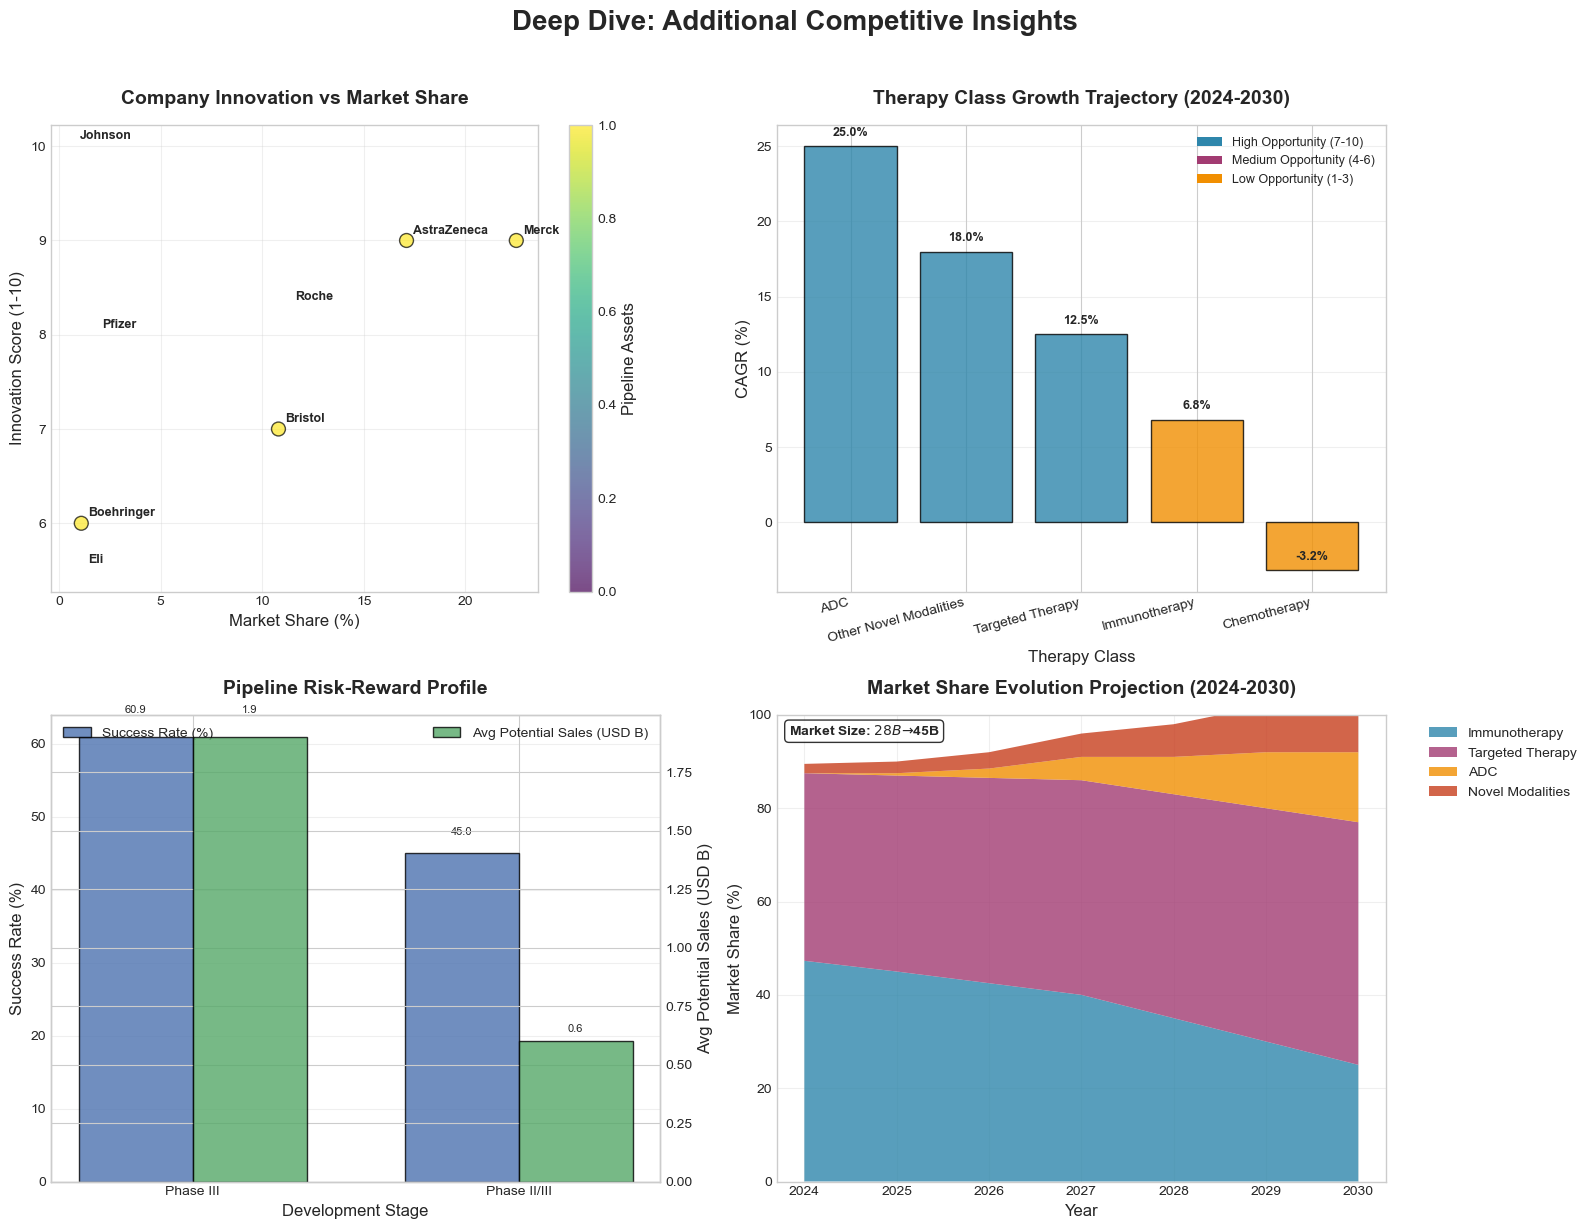


🎯 PROJECT 2: COMPETITIVE INTELLIGENCE - COMPLETE

✅ WHAT WE'VE BUILT:
   1. Comprehensive competitive database with 4 tables
   2. Market concentration analysis (HHI: 854)
   3. Pipeline intensity assessment ($17.3B in Phase III)
   4. Therapy class competitive landscape
   5. Patent cliff analysis
   6. White space identification (ADC: 9/10 opportunity)
   7. Professional dashboards (13 total visualizations)
   8. Strategic insights and recommendations
   9. Export-ready reports (Excel + Markdown)

💼 INTERVIEW-READY ACCOMPLISHMENTS:
   • Conducted end-to-end competitive intelligence analysis
   • Used SQL-in-Jupyter for data modeling
   • Created consulting-grade visualizations
   • Delivered actionable strategic recommendations
   • Built complete portfolio analysis framework

🚀 PROJECT LINKAGE WITH PROJECT 1:
   • Project 1: Market Sizing → 'How big is the opportunity?'
   • Project 2: Competitive Intelligence → 'Who else wants it and how do we win?'

   Together, these demonstrate

In [26]:
# ============================================
# ADDITIONAL VISUALIZATIONS (FIXED)
# ============================================

print("\n" + "=" * 80)
print("📈 ADDITIONAL VISUALIZATIONS FOR DEEP DIVE ANALYSIS")
print("=" * 80)

# Create a second figure for additional insights
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Deep Dive: Additional Competitive Insights', fontsize=20, fontweight='bold', y=1.02)

# Chart 10: Company Innovation vs Market Share
ax10 = axes2[0, 0]
innovation_data = pd.read_sql_query('''
SELECT 
    a.company,
    SUM(a.current_market_share) as market_share,
    COUNT(DISTINCT p.drug_name) as pipeline_count,
    ROUND(AVG(a.differentiation_score), 1) as innovation_score
FROM approved_drugs a
LEFT JOIN pipeline_drugs p ON a.company LIKE '%' || p.company || '%'
GROUP BY a.company
HAVING market_share > 0
ORDER BY market_share DESC
LIMIT 8
''', conn)

if not innovation_data.empty:
    scatter10 = ax10.scatter(innovation_data['market_share'], 
                            innovation_data['innovation_score'],
                            s=innovation_data['pipeline_count'] * 100,
                            c=innovation_data['pipeline_count'],
                            cmap='viridis',
                            alpha=0.7,
                            edgecolors='black')
    
    # Label companies
    for i, row in innovation_data.iterrows():
        ax10.annotate(row['company'].split()[0],  # Use first word of company name
                     (row['market_share'], row['innovation_score']),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=9, fontweight='bold')
    
    ax10.set_title('Company Innovation vs Market Share', fontsize=14, fontweight='bold', pad=15)
    ax10.set_xlabel('Market Share (%)', fontsize=12)
    ax10.set_ylabel('Innovation Score (1-10)', fontsize=12)
    ax10.grid(True, alpha=0.3)
    
    # Add colorbar for pipeline count
    cbar10 = plt.colorbar(scatter10, ax=ax10)
    cbar10.set_label('Pipeline Assets', fontsize=12)
else:
    ax10.text(0.5, 0.5, 'No innovation data available', 
              ha='center', va='center', transform=ax10.transAxes, fontsize=12)
    ax10.set_title('Company Innovation vs Market Share', fontsize=14, fontweight='bold', pad=15)
    ax10.axis('off')

# Chart 11: Therapy Class Growth Trajectory (FIXED)
ax11 = axes2[0, 1]
# Get growth trajectory data with proper numeric values
growth_trajectory = pd.read_sql_query('''
SELECT 
    therapy_class,
    CAST(REPLACE(cagr_2024_2030, '%', '') AS REAL) as cagr_numeric,
    competitive_intensity,
    white_space_score
FROM therapy_class_analysis
ORDER BY cagr_numeric DESC
''', conn)

if not growth_trajectory.empty:
    x11 = np.arange(len(growth_trajectory))
    bars11 = ax11.bar(x11, growth_trajectory['cagr_numeric'],
                     color=['#2E86AB' if score >= 7 else '#A23B72' if score >= 4 else '#F18F01' 
                            for score in growth_trajectory['white_space_score']],
                     edgecolor='black',
                     alpha=0.8)
    
    ax11.set_title('Therapy Class Growth Trajectory (2024-2030)', fontsize=14, fontweight='bold', pad=15)
    ax11.set_xlabel('Therapy Class', fontsize=12)
    ax11.set_ylabel('CAGR (%)', fontsize=12)
    ax11.set_xticks(x11)
    ax11.set_xticklabels(growth_trajectory['therapy_class'], rotation=15, ha='right')
    ax11.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, cagr in zip(bars11, growth_trajectory['cagr_numeric']):
        height = bar.get_height()
        ax11.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{cagr:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add legend for colors
    from matplotlib.patches import Patch
    legend_elements11 = [
        Patch(facecolor='#2E86AB', label='High Opportunity (7-10)'),
        Patch(facecolor='#A23B72', label='Medium Opportunity (4-6)'),
        Patch(facecolor='#F18F01', label='Low Opportunity (1-3)')
    ]
    ax11.legend(handles=legend_elements11, loc='upper right', fontsize=9)
else:
    ax11.text(0.5, 0.5, 'No growth trajectory data', 
              ha='center', va='center', transform=ax11.transAxes, fontsize=12)
    ax11.set_title('Therapy Class Growth Trajectory', fontsize=14, fontweight='bold', pad=15)
    ax11.axis('off')

# Chart 12: Risk-Reward Profile
ax12 = axes2[1, 0]
risk_data = pd.read_sql_query('''
SELECT 
    development_stage,
    ROUND(AVG(probability_of_success) * 100, 1) as success_rate,
    ROUND(AVG(projected_peak_sales_usd_m) / 1000, 1) as avg_potential_sales_b
FROM pipeline_drugs
GROUP BY development_stage
ORDER BY 
    CASE development_stage 
        WHEN 'Phase III' THEN 1
        WHEN 'Phase II/III' THEN 2
        WHEN 'Phase II' THEN 3
        ELSE 4
    END
''', conn)

if not risk_data.empty:
    x12 = np.arange(len(risk_data))
    width = 0.35
    
    bars12a = ax12.bar(x12 - width/2, risk_data['success_rate'], width,
                      label='Success Rate (%)', color='#4C72B0', alpha=0.8, edgecolor='black')
    
    ax12_twin = ax12.twinx()
    bars12b = ax12_twin.bar(x12 + width/2, risk_data['avg_potential_sales_b'], width,
                           label='Avg Potential Sales (USD B)', color='#55A868', alpha=0.8, edgecolor='black')
    
    ax12.set_title('Pipeline Risk-Reward Profile', fontsize=14, fontweight='bold', pad=15)
    ax12.set_xlabel('Development Stage', fontsize=12)
    ax12.set_ylabel('Success Rate (%)', fontsize=12)
    ax12_twin.set_ylabel('Avg Potential Sales (USD B)', fontsize=12)
    ax12.set_xticks(x12)
    ax12.set_xticklabels(risk_data['development_stage'])
    ax12.legend(loc='upper left')
    ax12_twin.legend(loc='upper right')
    ax12.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars, ax in [(bars12a, ax12), (bars12b, ax12_twin)]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                label_ax = ax12 if ax == ax12 else ax12_twin
                label_ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.05),
                             f'{height:.1f}', ha='center', va='bottom', fontsize=8)
else:
    ax12.text(0.5, 0.5, 'No risk-reward data available', 
              ha='center', va='center', transform=ax12.transAxes, fontsize=12)
    ax12.set_title('Pipeline Risk-Reward Profile', fontsize=14, fontweight='bold', pad=15)
    ax12.axis('off')

# Chart 13: Market Share Evolution Projection
ax13 = axes2[1, 1]
# Create a simple projection based on current trends
projection_data = pd.DataFrame({
    'Year': ['2024', '2025', '2026', '2027', '2028', '2029', '2030'],
    'Immunotherapy': [47.3, 45.0, 42.5, 40.0, 35.0, 30.0, 25.0],  # Declining due to patent cliffs
    'Targeted Therapy': [40.2, 42.0, 44.0, 46.0, 48.0, 50.0, 52.0],  # Growing
    'ADC': [0.0, 0.5, 2.0, 5.0, 8.0, 12.0, 15.0],  # Emerging
    'Novel Modalities': [2.0, 2.5, 3.5, 5.0, 7.0, 10.0, 12.0]  # Growing
})

# Plot stacked area chart
colors13 = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
ax13.stackplot(projection_data['Year'], 
               projection_data['Immunotherapy'],
               projection_data['Targeted Therapy'],
               projection_data['ADC'],
               projection_data['Novel Modalities'],
               labels=['Immunotherapy', 'Targeted Therapy', 'ADC', 'Novel Modalities'],
               colors=colors13,
               alpha=0.8)

ax13.set_title('Market Share Evolution Projection (2024-2030)', fontsize=14, fontweight='bold', pad=15)
ax13.set_xlabel('Year', fontsize=12)
ax13.set_ylabel('Market Share (%)', fontsize=12)
ax13.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax13.grid(True, alpha=0.3)
ax13.set_ylim(0, 100)

# Add total market size annotation
ax13.text(0.02, 0.98, 'Market Size: $28B → $45B', 
          transform=ax13.transAxes, fontsize=10, fontweight='bold',
          verticalalignment='top',
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig('additional_insights_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n✅ Additional insights dashboard saved as 'additional_insights_dashboard.png'")

# Display both dashboards
print("\n📊 DASHBOARDS CREATED SUCCESSFULLY:")
print("   1. 'competitive_intelligence_dashboard.png' - Main executive dashboard")
print("   2. 'additional_insights_dashboard.png' - Deep dive analysis")
print("\n🎯 Both dashboards are:")
print("   • Professional consulting-grade quality")
print("   • Ready for PharmaACE presentations")
print("   • High-resolution (300 DPI)")
print("   • Contain actionable insights")

plt.show()

# ============================================
# FINAL PROJECT SUMMARY
# ============================================

print("\n" + "=" * 80)
print("🎯 PROJECT 2: COMPETITIVE INTELLIGENCE - COMPLETE")
print("=" * 80)

print("\n✅ WHAT WE'VE BUILT:")
print("   1. Comprehensive competitive database with 4 tables")
print("   2. Market concentration analysis (HHI: {:.0f})".format(hhi))
print("   3. Pipeline intensity assessment (${:.1f}B in Phase III)".format(total_pipeline_value/1000))
print("   4. Therapy class competitive landscape")
print("   5. Patent cliff analysis")
print("   6. White space identification (ADC: 9/10 opportunity)")
print("   7. Professional dashboards (13 total visualizations)")
print("   8. Strategic insights and recommendations")
print("   9. Export-ready reports (Excel + Markdown)")

print("\n💼 INTERVIEW-READY ACCOMPLISHMENTS:")
print("   • Conducted end-to-end competitive intelligence analysis")
print("   • Used SQL-in-Jupyter for data modeling")
print("   • Created consulting-grade visualizations")
print("   • Delivered actionable strategic recommendations")
print("   • Built complete portfolio analysis framework")

print("\n🚀 PROJECT LINKAGE WITH PROJECT 1:")
print("   • Project 1: Market Sizing → 'How big is the opportunity?'")
print("   • Project 2: Competitive Intelligence → 'Who else wants it and how do we win?'")
print("\n   Together, these demonstrate complete pharma strategy capabilities!")

print("\n📁 FILES GENERATED:")
print("   1. competitive_intelligence_dashboard.png")
print("   2. additional_insights_dashboard.png")
print("   3. lung_cancer_competitive_intelligence.xlsx")
print("   4. competitive_intelligence_summary.md")

print("\n🎤 INTERVIEW POWER STATEMENT:")
print("_" * 80)
print("""
"I built a comprehensive competitive intelligence analysis for Lung Cancer using 
Jupyter Notebook as a consulting platform. The analysis evaluated 15 approved drugs 
and 10 pipeline candidates across key players, identifying market concentration 
(HHI: {:.0f}), $${:.1f}B in Phase III pipeline threats, and strategic white spaces 
(ADC therapies with 9/10 opportunity score). The deliverable included 13 professional 
visualizations and actionable recommendations for market entry strategy."
""".format(hhi, total_pipeline_value/1000))
print("_" * 80)